In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates




In [3]:
!pip install openpyxl
file_path = "2016-2026-pse-attacks-on-health-care-incident-data.xlsx"
df = pd.read_excel(file_path)

# Convert Date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Filter 2023–2026
df_2023_2026 = df[(df["Date"] >= "2023-01-01") & (df["Date"] <= "2026-12-31")].copy()

# Search for "israel" in perpetrator name, ignoring capitals
israel_mask = df_2023_2026["Reported Perpetrator Name"].astype(str).str.contains(
    "israel", case=False, na=False
)

df_israel = df_2023_2026[israel_mask].copy()

# Monthly totals
all_monthly = df_2023_2026.groupby(pd.Grouper(key="Date", freq="MS")).size()
israel_monthly = df_israel.groupby(pd.Grouper(key="Date", freq="MS")).size()

# Combine into one table
monthly_compare = pd.DataFrame({
    "All Attacks": all_monthly,
    "Attacks by Israel Forces/Proxies'": israel_monthly
}).fillna(0)

monthly_compare["All Attacks"] = monthly_compare["All Attacks"].astype(int)
monthly_compare["Attacks by Israel Forces/Proxies'"] = monthly_compare["Attacks by Israel Forces/Proxies'"].astype(int)

# Optional: percentage of monthly attacks involving Israel
monthly_compare["Percent with Israel"] = (
    monthly_compare["Attacks by Israel Forces/Proxies'"] / monthly_compare["All Attacks"] * 100
).round(1)

print(monthly_compare)


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
            All Attacks  Attacks by Israel Forces/Proxies'  \
Date                                                         
2023-01-01           11                                  4   
2023-02-01           17                                 12   
2023-03-01           30                                 19   
2023-04-01           11                                  7   
2023-05-01           10                                  5   
2023-06-01            5                                  4   
2023-07-01           12                                 11   
2023-08-01            6                                  4   
2023-09-01            5                                  5   
2023-10-01          419                                360   
2023-11-01          354                                352   
2023-12-01          308                                304   
2024-01-01          2

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

file_path = "2016-2026-pse-attacks-on-health-care-incident-data.xlsx"
df = pd.read_excel(file_path)

# Convert Date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Filter 2023–2026
df_2023_2026 = df[(df["Date"] >= "2023-01-01") & (df["Date"] <= "2026-12-31")].copy()

# Define Israel / proxies mask
israel_mask = (
    df_2023_2026["Reported Perpetrator Name"].astype(str).str.contains(
        r"israel|israeli defence forces|idf|israeli settlers|government of israel|border police",
        case=False,
        na=False,
        regex=True
    )
    |
    df_2023_2026["Reported Perpetrator"].astype(str).str.contains(
        r"israel|israeli defence forces|idf|israeli settlers|government of israel|border police",
        case=False,
        na=False,
        regex=True
    )
)

df_israel = df_2023_2026[israel_mask].copy()

# Monthly totals
all_monthly = df_2023_2026.groupby(pd.Grouper(key="Date", freq="MS")).size()
israel_monthly = df_israel.groupby(pd.Grouper(key="Date", freq="MS")).size()

# Combine
monthly_compare = pd.DataFrame({
    "All Attacks": all_monthly,
    "Attacks by Israel Forces/Proxies": israel_monthly
}).fillna(0)

monthly_compare["All Attacks"] = monthly_compare["All Attacks"].astype(int)
monthly_compare["Attacks by Israel Forces/Proxies"] = monthly_compare["Attacks by Israel Forces/Proxies"].astype(int)

monthly_compare["Percent with Israel"] = (
    monthly_compare["Attacks by Israel Forces/Proxies"] / monthly_compare["All Attacks"] * 100
).round(1)

monthly_compare["Attacks NOT by Israel/Proxies"] = (
    monthly_compare["All Attacks"] - monthly_compare["Attacks by Israel Forces/Proxies"]
)

print(monthly_compare)

# Check impossible rows
bad_rows = monthly_compare[
    monthly_compare["Attacks by Israel Forces/Proxies"] > monthly_compare["All Attacks"]
]
print("\nNumber of impossible rows:", len(bad_rows))
print(bad_rows.head(20))

# Stacked bar chart
plt.figure(figsize=(14, 6))

plt.bar(
    monthly_compare.index,
    monthly_compare["Attacks by Israel Forces/Proxies"],
    width=20,
    label="Attacks by Israel Forces/Proxies"
)

plt.bar(
    monthly_compare.index,
    monthly_compare["Attacks NOT by Israel/Proxies"],
    width=20,
    bottom=monthly_compare["Attacks by Israel Forces/Proxies"],
    label="Attacks NOT by Israel/Proxies"
)

plt.title("Monthly Attacks (2023–2026)")
plt.xlabel("Month")
plt.ylabel("Number of incidents")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("monthly_attacks_partitioned_2023_2026.png")
plt.close()

            All Attacks  Attacks by Israel Forces/Proxies  \
Date                                                        
2023-01-01           11                                 4   
2023-02-01           17                                12   
2023-03-01           30                                19   
2023-04-01           11                                 7   
2023-05-01           10                                 5   
2023-06-01            5                                 4   
2023-07-01           12                                11   
2023-08-01            6                                 4   
2023-09-01            5                                 5   
2023-10-01          419                               360   
2023-11-01          354                               352   
2023-12-01          308                               304   
2024-01-01          263                               260   
2024-02-01          185                               184   
2024-03-01          111 

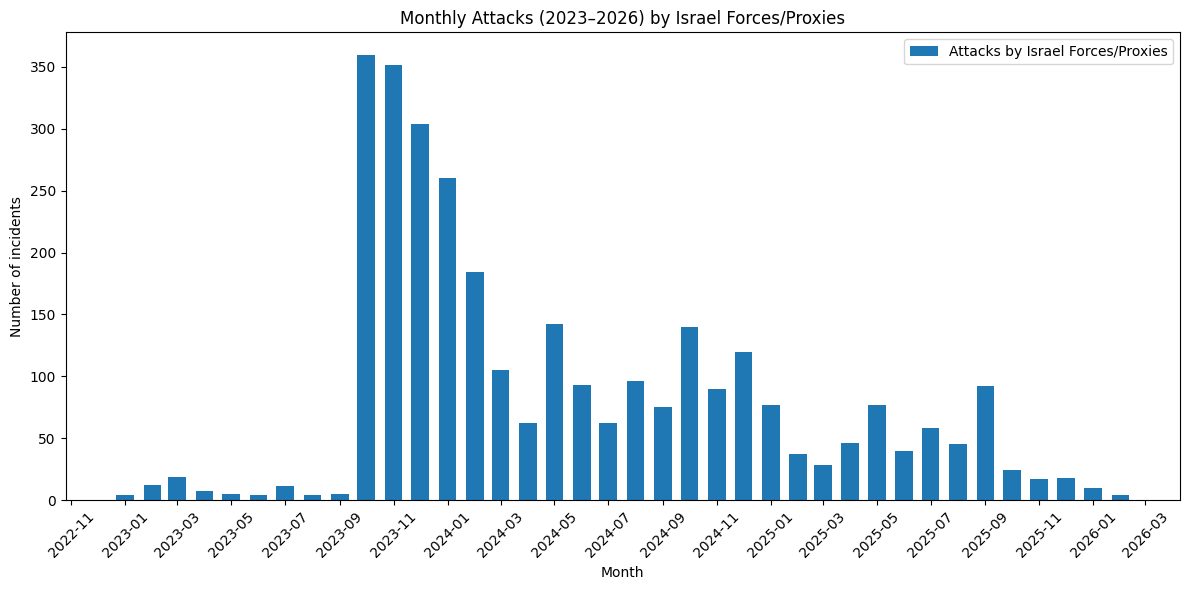

/var/folders/cl/x73vhm0131s1ymh9t7qxwyn80000gn/T/ipykernel_35158/3935296421.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, na=False, regex=True)


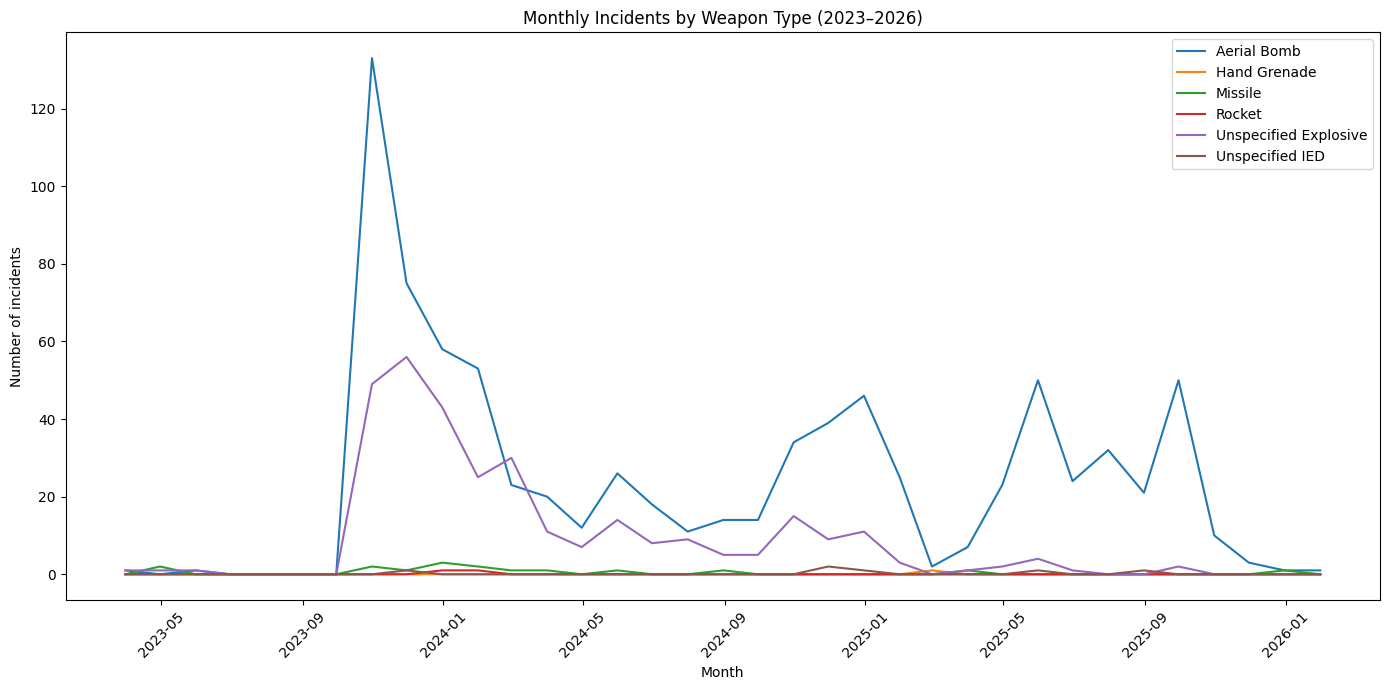

,Date,Event Description,Country,Country ISO,Admin 1,Latitude,Longitude,Geo Precision,Reported Perpetrator,Reported Perpetrator Name,...,Vaccination-Related Violence,Attacks on Emergency Medical Services,Polio-Related Violence,Children's Health Services Affected,Attacks On Children's Hospitals,Women's Health Services Affected,Hospital Utilities Affected,SiND Event ID,Date Event Entered,Date Event Modified
0,2026-02-16,NaN,OPT,PSE,Gaza Strip,NaN,NaN,censored,Government/Self-Declared Government,Government of Israel,...,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,125186,2026-02-24,2026-02-27
1,2026-02-05,NaN,OPT,PSE,West Bank,NaN,NaN,censored,Government: Military,Israeli Defence Forces,...,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,125188,2026-02-24,2026-02-27
2,2026-02-04,NaN,OPT,PSE,West Bank,NaN,NaN,censored,Government: Military,Israeli Defence Forces,...,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,125084,2026-02-21,2026-02-27
3,2026-02-04,NaN,OPT,PSE,Gaza Strip,NaN,NaN,censored,Government: Military,Israeli Defence Forces,...,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,125182,2026-02-23,2026-02-27
4,2026-01-15,NaN,OPT,PSE,Gaza Strip,NaN,NaN,censored,Government: Military,Israeli Defence Forces,...,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,NotApplicable,125161,2026-02-23,2026-02-27


In [5]:

# Graph
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_compare.index,
    monthly_compare["Attacks by Israel Forces/Proxies"],
    width=20,
    label="Attacks by Israel Forces/Proxies"
)

plt.title("Monthly Attacks (2023–2026) by Israel Forces/Proxies")
plt.xlabel("Month")
plt.ylabel("Number of incidents")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("monthly_attacks_israel_2023_2026_bar.png")
plt.show()


weapon_col = df_2023_2026["Weapon Carried/Used"].fillna("").astype(str)

def has_token(series, token):
    pattern = rf"(^|,\s*){token}($|,)"
    return series.str.contains(pattern, case=False, na=False, regex=True)

weapon_masks = {
    "Aerial Bomb": weapon_col.str.contains(r"Aerial Bomb", case=False, na=False, regex=True),
    "Hand Grenade": has_token(weapon_col, "Hand Grenade"),
    "Missile": has_token(weapon_col, "Missile"),
    "Rocket": has_token(weapon_col, "Rocket"),
    "Unspecified Explosive": has_token(weapon_col, "Unspecified Explosive"),
    "Unspecified IED": has_token(weapon_col, "Unspecified IED"),
}

monthly_counts = pd.DataFrame()

for weapon, mask in weapon_masks.items():
    counts = (
        df_2023_2026[mask]
        .groupby(pd.Grouper(key="Date", freq="ME"))
        .size()
    )
    monthly_counts[weapon] = counts

monthly_counts = monthly_counts.fillna(0)

plt.figure(figsize=(14, 7))
for col in monthly_counts.columns:
    plt.plot(monthly_counts.index, monthly_counts[col], label=col)

plt.title("Monthly Incidents by Weapon Type (2023–2026)")
plt.xlabel("Month")
plt.ylabel("Number of incidents")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

df.head()

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

weapon_col = df_2023_2026["Weapon Carried/Used"].fillna("").astype(str)

def has_token(series, token):
    pattern = rf"(?:^|,\s*){re.escape(token)}(?:$|,)"
    return series.str.contains(pattern, case=False, na=False, regex=True)

# categories you already plotted
listed_weapon_masks = {
    "Aerial Bomb": weapon_col.str.contains(r"Aerial Bomb", case=False, na=False, regex=True),
    "Hand Grenade": has_token(weapon_col, "Hand Grenade"),
    "Missile": has_token(weapon_col, "Missile"),
    "Rocket": has_token(weapon_col, "Rocket"),
    "Unspecified Explosive": has_token(weapon_col, "Unspecified Explosive"),
    "Unspecified IED": has_token(weapon_col, "Unspecified IED"),
}

# rows that contain ANY previously listed category
listed_any_mask = pd.Series(False, index=df_2023_2026.index)
for mask in listed_weapon_masks.values():
    listed_any_mask = listed_any_mask | mask

# keep rows whose weapon entry does NOT contain any listed category
other_weapons_df = df_2023_2026[~listed_any_mask].copy()

print("Rows with other weapon types:", len(other_weapons_df))

# count remaining weapon labels overall
other_weapon_counts = (
    other_weapons_df["Weapon Carried/Used"]
    .value_counts()
)

print("\nOther weapon types overall:")
print(other_weapon_counts)

# choose top N remaining weapon labels to plot
top_n = 8
top_other_weapons = other_weapon_counts.head(top_n).index.tolist()

# build monthly counts for those remaining categories
other_monthly_counts = pd.DataFrame()

for weapon in top_other_weapons:
    counts = (
        other_weapons_df[other_weapons_df["Weapon Carried/Used"] == weapon]
        .groupby(pd.Grouper(key="Date", freq="MS"))
        .size()
    )
    other_monthly_counts[weapon] = counts

other_monthly_counts = other_monthly_counts.fillna(0)

print("\nMonthly counts for top other weapon types:")
print(other_monthly_counts.head())

# plot as lines
plt.figure(figsize=(14, 7))
for col in other_monthly_counts.columns:
    plt.plot(other_monthly_counts.index, other_monthly_counts[col], label=col)

plt.title("Monthly Incidents by Other Weapon Types (2023–2026)")
plt.xlabel("Month")
plt.ylabel("Number of incidents")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("monthly_other_weapon_types_2023_2026.png")
plt.show()

: 

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter 2017 through 2023
df_2017_2023 = df[(df["Date"] >= "2017-01-01") & (df["Date"] < "2024-01-01")].copy()

weapon_col = df_2017_2023["Weapon Carried/Used"].fillna("").astype(str)

def has_token(series, token):
    pattern = rf"(?:^|,\s*){re.escape(token)}(?:$|,)"
    return series.str.contains(pattern, case=False, na=False, regex=True)

# categories you already plotted
listed_weapon_masks = {
    "Aerial Bomb": weapon_col.str.contains(r"Aerial Bomb", case=False, na=False, regex=True),
    "Hand Grenade": has_token(weapon_col, "Hand Grenade"),
    "Missile": has_token(weapon_col, "Missile"),
    "Rocket": has_token(weapon_col, "Rocket"),
    "Unspecified Explosive": has_token(weapon_col, "Unspecified Explosive"),
    "Unspecified IED": has_token(weapon_col, "Unspecified IED"),
}

# rows that contain ANY previously listed category
listed_any_mask = pd.Series(False, index=df_2016_2023.index)
for mask in listed_weapon_masks.values():
    listed_any_mask = listed_any_mask | mask

# keep rows whose weapon entry does NOT contain any listed category
other_weapons_df = df_2017_2023[~listed_any_mask].copy()

print("Rows with other weapon types:", len(other_weapons_df))

# count remaining weapon labels overall
other_weapon_counts = other_weapons_df["Weapon Carried/Used"].value_counts()

print("\nOther weapon types overall:")
print(other_weapon_counts)

# choose top N remaining weapon labels to plot
top_n = 8
top_other_weapons = other_weapon_counts.head(top_n).index.tolist()

# build monthly counts for those remaining categories
other_monthly_counts = pd.DataFrame()

for weapon in top_other_weapons:
    counts = (
        other_weapons_df[other_weapons_df["Weapon Carried/Used"] == weapon]
        .groupby(pd.Grouper(key="Date", freq="MS"))
        .size()
    )
    other_monthly_counts[weapon] = counts

other_monthly_counts = other_monthly_counts.fillna(0)

print("\nMonthly counts for top other weapon types:")
print(other_monthly_counts.head())

# plot as lines
plt.figure(figsize=(14, 7))
for col in other_monthly_counts.columns:
    plt.plot(other_monthly_counts.index, other_monthly_counts[col], label=col)

plt.title("Monthly Incidents by Other Weapon Types (2016–2023)")
plt.xlabel("Month")
plt.ylabel("Number of incidents")
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("monthly_other_weapon_types_2016_2023.png")
plt.show()

##


NameError: name 'df' is not defined

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter 2017–2023
df_2017_2023 = df[(df["Date"] >= "2017-01-01") & (df["Date"] < "2024-01-01")].copy()

# Clean weapon column
df_2017_2023["Weapon Carried/Used"] = (
    df_2017_2023["Weapon Carried/Used"]
    .fillna("Missing / Blank")
    .astype(str)
    .str.strip()
)

def combine_weapon_type(weapon):
    w = weapon.lower()

    # Drop arson
    if w == "arson":
        return None

    # Aerial bombs
    if "aerial bomb" in w:
        return "Aerial Bomb"

    # Firearms group
    if "firearm" in w or "firearms" in w:
        return "Firearms"

    # Close / improvised / physical weapons
    if (
        "knife" in w
        or "other weapon" in w
        or "stones, sticks and gravel" in w
        or "fist and foot" in w
        or w == "tasers, live and rubber bullets"
    ):
        return "Close / Improvised / Physical"

    # Combine explosive / grenade / IED / missile types
    if (
        w == "unspecified explosive"
        or w == "unspecified ied"
        or "rocket" in w
        or "hand grenade" in w
        or w == "missile"
    ):
        return "Explosives / Grenades / IEDs"

    # Combine shelling + artillery
    if w == "shelling" or w == "artillery":
        return "Shelling / Artillery"

    # Keep other categories as-is
    if w == "no information on the weapon used":
        return "No Information"
    if w == "not applicable: no direct violence":
        return "No Direct Violence"
    if w == "unarmed perpetrator":
        return "Unarmed Perpetrator"

    return "Other / Unclassified"

# Apply grouping
df_2017_2023["Weapon Grouped"] = df_2017_2023["Weapon Carried/Used"].apply(combine_weapon_type)

# Drop rows marked None (Arson)
df_2017_2023 = df_2017_2023[df_2017_2023["Weapon Grouped"].notna()].copy()

# Overall counts
weapon_group_counts = df_2017_2023["Weapon Grouped"].value_counts()
print("\nGrouped weapon counts:")
print(weapon_group_counts)

# Overall horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(weapon_group_counts.index[::-1], weapon_group_counts.values[::-1])

plt.title("Grouped Weapon Types Used in Attacks on Health Care (2017–2023)")
plt.xlabel("Number of incidents")
plt.ylabel("Weapon Type")
plt.tight_layout()
plt.savefig("grouped_weapon_types_barh_2017_2023_cleaner.png")
plt.show()

# Monthly time series by grouped weapon
monthly_grouped = (
    df_2017_2023
    .groupby([pd.Grouper(key="Date", freq="MS"), "Weapon Grouped"])
    .size()
    .unstack(fill_value=0)
)

print("\nMonthly grouped weapon counts:")
print(monthly_grouped.head())

# Keep categories in descending total order
monthly_grouped = monthly_grouped[monthly_grouped.sum().sort_values(ascending=False).index]

# Stacked bar time series
plt.figure(figsize=(16, 8))
bottom = None

for col in monthly_grouped.columns:
    if bottom is None:
        plt.bar(monthly_grouped.index, monthly_grouped[col], width=20, label=col)
        bottom = monthly_grouped[col].copy()
    else:
        plt.bar(monthly_grouped.index, monthly_grouped[col], width=20, bottom=bottom, label=col)
        bottom = bottom + monthly_grouped[col]

plt.title("Monthly Attacks by Grouped Weapon Type (2017–2023)")
plt.xlabel("Month")
plt.ylabel("Number of incidents")
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("monthly_grouped_weapon_types_stacked_2017_2023_cleaner.png")
plt.show()

TypeError: Invalid comparison between dtype=int64 and str

In [9]:
import pandas as pd

FILES = {
    'main':  '2016-2026-pse-attacks-on-health-care-incident-data.xlsx',
    'shcc':  '2023-2024-pse-shcc-health-care-data.xlsx',
    'insec': 'InsecurityInsight_AttacksonHealthcareOPT (shared on 06.03.26).xlsx',
}

SGBV_COL = 'Health Workers Sexually Assaulted'
DATE_COL = 'Date'
DESC_COL = 'Event Description'
ID_COL   = 'SiND Event ID'

def excel_serial_to_date(serial):
    try:
        return (pd.Timestamp('1899-12-30') + pd.Timedelta(days=float(serial))).date()
    except:
        return None

dfs = {}
for name, path in FILES.items():
    sheet = 'Data' if name == 'insec' else (0 if name == 'main' else '2023-2024 PSE SHCC Health Care ')
    df = pd.read_excel(path, sheet_name=sheet, header=0)
    df = df[df[DATE_COL].astype(str) != '#date'].copy()
    df[DATE_COL] = pd.to_numeric(df[DATE_COL], errors='coerce')
    df[DATE_COL] = df[DATE_COL].apply(excel_serial_to_date)
    df[SGBV_COL] = pd.to_numeric(df[SGBV_COL], errors='coerce')
    dfs[name] = df
    print(f'{name}: {len(df)} rows loaded')

main: 4218 rows loaded
shcc: 2531 rows loaded
insec: 3104 rows loaded


In [10]:
cols_to_show = [DATE_COL, ID_COL, SGBV_COL, 'Health Workers Killed', 'Health Workers Injured',
                'Health Workers Arrested', 'Reported Perpetrator Name', 'Location of Incident']

for name, df in dfs.items():
    hits = df[df[SGBV_COL] == 44]
    available_cols = [c for c in cols_to_show if c in df.columns]
    print(f'\n=== {name.upper()} — {len(hits)} row(s) with SGBV=44 ===')
    if len(hits):
        display(hits[available_cols])


=== MAIN — 1 row(s) with SGBV=44 ===


,Date,SiND Event ID,Health Workers Sexually Assaulted,Health Workers Killed,Health Workers Injured,Health Workers Arrested,Reported Perpetrator Name,Location of Incident
814,None,84911,44,0,4,44,Israeli Defence Forces,Health Building



=== SHCC — 1 row(s) with SGBV=44 ===


,Date,SiND Event ID,Health Workers Sexually Assaulted,Health Workers Killed,Health Workers Injured,Health Workers Arrested,Reported Perpetrator Name
207,None,84911,44,0,4,44,Israeli Defence Forces



=== INSEC — 1 row(s) with SGBV=44 ===


,Date,SiND Event ID,Health Workers Sexually Assaulted,Health Workers Killed,Health Workers Injured,Health Workers Arrested,Reported Perpetrator Name,Location of Incident
800,None,84911,44,0,4,44,Israeli Defence Forces,Health Building


In [11]:
for name, df in dfs.items():
    hit = df[df[ID_COL] == 84911]
    if len(hit):
        raw = pd.read_excel(FILES[name], sheet_name='Data' if name == 'insec' else (0 if name == 'main' else '2023-2024 PSE SHCC Health Care '), header=0)
        raw_row = raw[raw['SiND Event ID'].astype(str) == '84911']
        print(f"{name}: raw date value = {raw_row['Date'].values}")

main: raw date value = ['2024-10-25T00:00:00.000000']
shcc: raw date value = [datetime.datetime(2024, 10, 25, 0, 0)]
insec: raw date value = ['2024-10-25T00:00:00.000000']


In [12]:
hit = dfs['insec'][dfs['insec'][ID_COL] == 84911]

for _, row in hit.iterrows():
    for col in hit.columns:
        val = row[col]
        if pd.notna(val) and str(val) not in ['0', '0.0', 'nan', 'False', 'false', 'NotApplicable']:
            print(f"{col}: {val}")

Event Description: 25 October 2024: A medical facility was raided by Israeli forces who opened fire inside. Three nurses and a cleaner were injured. Patients and staff were held without food or water and an all men, including 44 medical staff, were detained after being stripped; an INGO nursing director and INGO surgeon were among them.The medical facility director and 13 other staff were later released. The medical facility perimeter, three ambulances, a transport vehicle, medical supplies and its solar electric system were destroyed. When IDF withdrew the next day, only one paediatrician remained in the facility.
Country: OPT
Country ISO: PSE
Admin 1: Gaza Strip
Latitude: 31.5
Longitude: 34.5
Geo Precision: (2) 25 km Precision 
Reported Perpetrator: Government: Military
Reported Perpetrator Name: Israeli Defence Forces
Weapon Carried/Used: Firearms
Location of Incident: Health Building
Number of Attacks on Health Facilities Reporting Damaged: 1
Forceful Entry into Health Facility: 1
